# Project 9: Tourism Experience Analytics — Classification, Prediction, and Recommendation System

**Domain:** Tourism

**Objectives:**
1. **Regression** — predict a user's rating for an attraction (1–5)
2. **Classification** — predict the user's VisitMode (Business, Family, Couples, Friends, etc.)
3. **Recommendation** — suggest attractions via collaborative + content-based filtering

**Deliverable:** Streamlit app producing a VisitMode prediction and a ranked list of recommended attractions from user inputs.

---


## Section 1: Know Your Data

In [1]:
# Core imports
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATA_DIR = 'data/'


### 1.1 Load all datasets

Actual files are `.xlsx` (not `.csv`), and the visit-mode table is named `Mode.xlsx`. There's also an `Updated_Item.xlsx` alongside `Item.xlsx` — we're using `Item.xlsx` as the attraction source of truth per your confirmation.

Requires `openpyxl`: `pip install openpyxl` if not already in the `p9` venv.

In [2]:
transaction_df = pd.read_excel(DATA_DIR + 'Transaction.xlsx')
user_df        = pd.read_excel(DATA_DIR + 'User.xlsx')
city_df        = pd.read_excel(DATA_DIR + 'City.xlsx')
type_df        = pd.read_excel(DATA_DIR + 'Type.xlsx')
visitmode_df   = pd.read_excel(DATA_DIR + 'Mode.xlsx')
continent_df   = pd.read_excel(DATA_DIR + 'Continent.xlsx')
country_df     = pd.read_excel(DATA_DIR + 'Country.xlsx')
region_df      = pd.read_excel(DATA_DIR + 'Region.xlsx')
item_df        = pd.read_excel(DATA_DIR + 'Item.xlsx')
# Updated_Item.xlsx intentionally not loaded — Item.xlsx confirmed as the attraction source of truth

datasets = {
    'Transaction': transaction_df, 'User': user_df, 'City': city_df,
    'Type': type_df, 'VisitMode': visitmode_df, 'Continent': continent_df,
    'Country': country_df, 'Region': region_df, 'Item': item_df
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")


Transaction: (52930, 7)
User: (33530, 5)
City: (9143, 3)
Type: (17, 2)
VisitMode: (6, 2)
Continent: (6, 2)
Country: (165, 3)
Region: (22, 3)
Item: (30, 5)


### 1.2 First look at each table

In [3]:
for name, df in datasets.items():
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    display(df.head(3))



Transaction


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5



User


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0



City


...

,CountryId,Country,RegionId
0,0,-,0
1,1,Cameroon,1
2,2,Chad,1



Region


,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1



Item


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"


### 1.3 Structure, dtypes, nulls

In [4]:
for name, df in datasets.items():
    print(f"\n{'='*60}\n{name} — info\n{'='*60}")
    df.info()



Transaction — info
<class 'pandas.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB

User — info
<class 'pandas.DataFrame'>
RangeIndex: 33530 entries, 0 to 33529
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UserId       33530 non-null  int64  
 1   ContinentId  33530 non-null  int64  
 2   RegionId     33530 non-null  int64  
 3   CountryId    33530 non-null  int64  
 4   CityId       33526 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 1.3 MB

City — info


In [5]:
for name, df in datasets.items():
    print(f"\n{'='*60}\n{name} — info\n{'='*60}")
    df.info()



Transaction — info
<class 'pandas.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB

User — info
<class 'pandas.DataFrame'>
RangeIndex: 33530 entries, 0 to 33529
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UserId       33530 non-null  int64  
 1   ContinentId  33530 non-null  int64  
 2   RegionId     33530 non-null  int64  
 3   CountryId    33530 non-null  int64  
 4   CityId       33526 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 1.3 MB

City — info


In [6]:
print("Null counts per table:\n")
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"\n{name}:")
        print(nulls)
    else:
        print(f"\n{name}: no nulls")


Null counts per table:


Transaction: no nulls

User:
CityId    4
dtype: int64

City:
CityName    1
dtype: int64

Type: no nulls

VisitMode: no nulls

Continent: no nulls

Country: no nulls

Region: no nulls

Item: no nulls


In [7]:
print("Duplicate rows per table:\n")
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")


Duplicate rows per table:

Transaction: 0 duplicates
User: 0 duplicates
City: 0 duplicates
Type: 0 duplicates
VisitMode: 0 duplicates
Continent: 0 duplicates
Country: 0 duplicates
Region: 0 duplicates
Item: 0 duplicates


## Section 2: Understanding Your Variables

### 2.1 Transaction table — the core fact table

In [9]:
transaction_df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
TransactionId,52930.0,70415.130474,66299.514206,3.0,19646.25,42770.5,105638.75,211241.0
UserId,52930.0,45024.522596,25073.062199,14.0,23470.00,45533.5,66667.00,88190.0
VisitYear,52930.0,2016.351899,1.732926,2013.0,2015.00,2016.0,2018.00,2022.0
VisitMonth,52930.0,6.633100,3.392979,1.0,4.00,7.0,9.00,12.0
VisitMode,52930.0,2.945759,1.000683,1.0,2.00,3.0,4.00,5.0
AttractionId,52930.0,759.663782,210.716111,369.0,640.00,737.0,841.00,1297.0
Rating,52930.0,4.157699,0.970543,1.0,4.00,4.0,5.00,5.0


In [10]:
print("VisitYear range:", transaction_df['VisitYear'].min(), '-', transaction_df['VisitYear'].max())
print("VisitMonth range:", transaction_df['VisitMonth'].min(), '-', transaction_df['VisitMonth'].max())
print("\nRating distribution:")
print(transaction_df['Rating'].value_counts().sort_index())
print("\nVisitMode (raw id) distribution:")
print(transaction_df['VisitMode'].value_counts())


VisitYear range: 2013 - 2022
VisitMonth range: 1 - 12

Rating distribution:
Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64

VisitMode (raw id) distribution:
VisitMode
2    21620
3    15217
4    10945
5     4525
1      623
Name: count, dtype: int64


### 2.2 Cardinality check across dimension tables

In [11]:
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} cols -> {list(df.columns)}")


Transaction: 52930 rows, 7 cols -> ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']
User: 33530 rows, 5 cols -> ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']
City: 9143 rows, 3 cols -> ['CityId', 'CityName', 'CountryId']
Type: 17 rows, 2 cols -> ['AttractionTypeId', 'AttractionType']
VisitMode: 6 rows, 2 cols -> ['VisitModeId', 'VisitMode']
Continent: 6 rows, 2 cols -> ['ContinentId', 'Continent']
Country: 165 rows, 3 cols -> ['CountryId', 'Country', 'RegionId']
Region: 22 rows, 3 cols -> ['Region', 'RegionId', 'ContinentId']
Item: 30 rows, 5 cols -> ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']


### 2.3 Categorical variable inventory

In [12]:
print("Attraction Types:")
print(type_df['AttractionType'].unique())
print("\nVisit Modes:")
print(visitmode_df['VisitMode'].unique())
print("\nContinents:")
print(continent_df['Continent'].unique())


Attraction Types:
<StringArray>
[                 'Ancient Ruins',                        'Ballets',                        'Beaches',                'Caverns & Caves',          'Flea & Street Markets',
                 'Historic Sites',                'History Museums',                 'National Parks',        'Nature & Wildlife Areas',                  'Neighborhoods',
 'Points of Interest & Landmarks',                'Religious Sites',                           'Spas',             'Speciality Museums',                       'Volcanos',
                    'Water Parks',                     'Waterfalls']
Length: 17, dtype: str

Visit Modes:
<StringArray>
['-', 'Business', 'Couples', 'Family', 'Friends', 'Solo']
Length: 6, dtype: str

Continents:
<StringArray>
['-', 'Africa', 'America', 'Asia', 'Australia & Oceania', 'Europe']
Length: 6, dtype: str


## Section 3: Data Wrangling

### 3.1 Standardize categorical variables

In [14]:
# Strip whitespace / normalize case on key categorical columns before joining
for df, col in [(city_df, 'CityName'), (country_df, 'Country'), (region_df, 'Region'),
                (continent_df, 'Continent'), (type_df, 'AttractionType'), (visitmode_df, 'VisitMode')]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Check for near-duplicate city/country names (common data quality issue)
# .dropna().astype(str) here makes this line self-contained even if cells get
# re-run out of order in VS Code (so it doesn't depend on the loop above having run first)
print("Unique city name count:", city_df['CityName'].nunique())
print("Sample sorted city names (scan for near-duplicates like 'New York' vs 'New york'):")
print(sorted(city_df['CityName'].dropna().astype(str).unique())[:30])


Unique city name count: 8767
Sample sorted city names (scan for near-duplicates like 'New York' vs 'New york'):
['-', 'Aachen', 'Aalborg', 'Aalsgaarde', 'Aalsmeer', 'Aalst', 'Aarau', 'Aarhus', 'Aarschot', 'Ababi', 'Abbotsford', 'Abbottabad', 'Aberaeron', 'Abercorn', 'Aberdare', 'Aberdeen', 'Aberdeenshire', 'Aberfoyle Park', 'Abergavenny', 'Aberporth', 'Abertillery', 'Aberystwyth', 'Abidjan', 'Abingdon', 'Abohar', 'Absam', 'Abu Dhabi', 'Abuja', 'Acacia Ridge', 'Acapulco']


### 3.2 Merge all tables into one master dataframe

In [15]:
master_df = transaction_df.copy()

# Transaction -> User
master_df = master_df.merge(user_df, on='UserId', how='left')

# User -> City -> Country -> Region -> Continent
master_df = master_df.merge(city_df, on='CityId', how='left', suffixes=('', '_city'))
master_df = master_df.merge(country_df, on='CountryId', how='left', suffixes=('', '_country'))
master_df = master_df.merge(region_df, on='RegionId', how='left', suffixes=('', '_region'))
master_df = master_df.merge(continent_df, on='ContinentId', how='left', suffixes=('', '_continent'))

# Transaction -> Item (Attraction)
master_df = master_df.merge(item_df, on='AttractionId', how='left', suffixes=('', '_item'))

# Item -> AttractionType
master_df = master_df.merge(type_df, on='AttractionTypeId', how='left', suffixes=('', '_type'))

# Transaction -> VisitMode label
# Note: Transaction's 'VisitMode' column holds an integer ID, while Mode.xlsx's 'VisitMode'
# column holds the text label -- same column name, different meaning, so merging on matching
# name fails with an int64-vs-str error. Mode.xlsx's first column is the ID, second is the label
# (standard lookup-table layout) -- rename both to disambiguate before merging.
print("Mode.xlsx columns:", visitmode_df.columns.tolist())
mode_id_col, mode_label_col = visitmode_df.columns[0], visitmode_df.columns[1]

mode_lookup = visitmode_df.rename(columns={mode_id_col: 'VisitModeId_lookup', mode_label_col: 'VisitMode_label'})
master_df = master_df.merge(
    mode_lookup[['VisitModeId_lookup', 'VisitMode_label']],
    left_on='VisitMode', right_on='VisitModeId_lookup', how='left'
)
master_df = master_df.drop(columns=['VisitModeId_lookup'])

print("Master dataframe shape:", master_df.shape)
master_df.head()


Mode.xlsx columns: ['VisitModeId', 'VisitMode']
Master dataframe shape: (52930, 24)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,CityName,CountryId_city,Country,RegionId_country,Region,ContinentId_region,Continent,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,VisitMode_label
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,Guildford,109.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Couples
1,8,7567,2022,10,4,640,5,2,8,48,464.0,Ontario,48.0,Canada,8,Northern America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Friends
2,9,79069,2022,10,3,640,5,2,9,54,774.0,Brazil,51.0,Brazil,9,South America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Family
3,10,31019,2022,10,3,640,3,5,17,135,583.0,Zurich,48.0,Switzerland,17,Central Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Family
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,Manchester,51.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Couples


### 3.3 Handle missing values post-merge

In [16]:
print("Nulls in master_df after merge:")
null_summary = master_df.isnull().sum()
print(null_summary[null_summary > 0])


Nulls in master_df after merge:
CityId            8
CityName          8
CountryId_city    8
dtype: int64


In [17]:
# Drop rows with missing target (Rating) — can't train on those
master_df = master_df.dropna(subset=['Rating'])

# Fill missing categorical joins with 'Unknown' rather than dropping (preserves row count)
categorical_fill_cols = ['AttractionType', 'Continent', 'Country', 'Region', 'CityName']
for col in categorical_fill_cols:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna('Unknown')

print("Shape after handling nulls:", master_df.shape)


Shape after handling nulls: (52930, 24)


### 3.4 Date/time standardization

In [18]:
# Build a proper datetime column from VisitYear + VisitMonth for trend analysis
master_df['VisitDate'] = pd.to_datetime(
    master_df['VisitYear'].astype(str) + '-' + master_df['VisitMonth'].astype(str) + '-01',
    format='%Y-%m-%d', errors='coerce'
)
print(master_df['VisitDate'].min(), '->', master_df['VisitDate'].max())
print("Rows with unparseable dates:", master_df['VisitDate'].isnull().sum())


2013-01-01 00:00:00 -> 2022-10-01 00:00:00
Rows with unparseable dates: 0


### 3.5 Outlier / invalid entry checks

In [19]:
# Rating should be within a known scale (commonly 1-5) — flag anything outside
print("Rating value counts (look for out-of-range values):")
print(master_df['Rating'].value_counts().sort_index())

invalid_ratings = master_df[(master_df['Rating'] < 1) | (master_df['Rating'] > 5)]
print(f"\nInvalid rating rows: {len(invalid_ratings)}")


Rating value counts (look for out-of-range values):
Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64

Invalid rating rows: 0


In [20]:
# Duplicate transactions
dupes = master_df.duplicated(subset=['UserId', 'AttractionId', 'VisitYear', 'VisitMonth'], keep=False)
print(f"Potential duplicate visit records: {dupes.sum()}")


Potential duplicate visit records: 8778


## Section 4: Data Visualization

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


### 4.1 Rating distribution

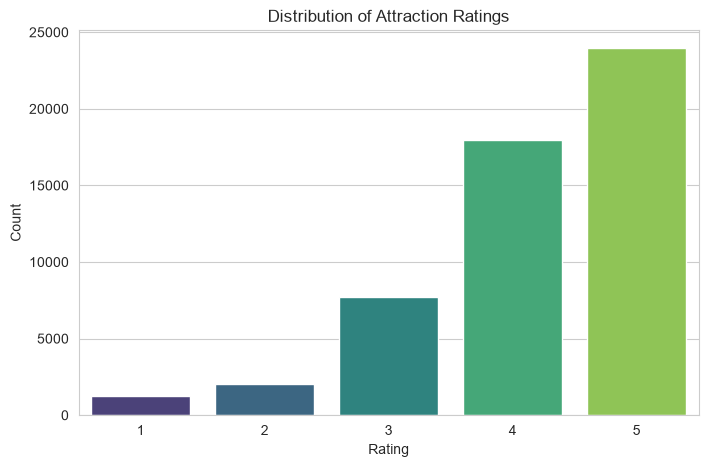

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=master_df, x='Rating', palette='viridis')
plt.title('Distribution of Attraction Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


### 4.2 VisitMode distribution

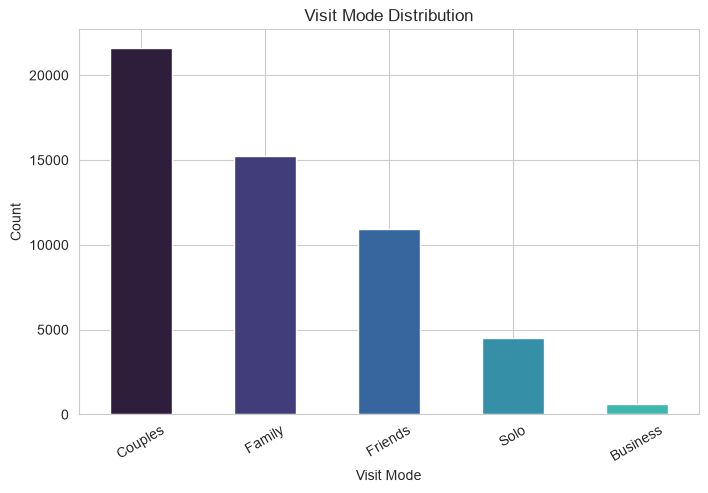

In [25]:
visitmode_col = 'VisitMode_label'  # set in Section 3.2 after resolving the ID/label column name clash
plt.figure(figsize=(8,5))
master_df[visitmode_col].value_counts().plot(kind='bar', color=sns.color_palette('mako', 6))
plt.title('Visit Mode Distribution')
plt.xlabel('Visit Mode')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()


### 4.3 User distribution by continent / country

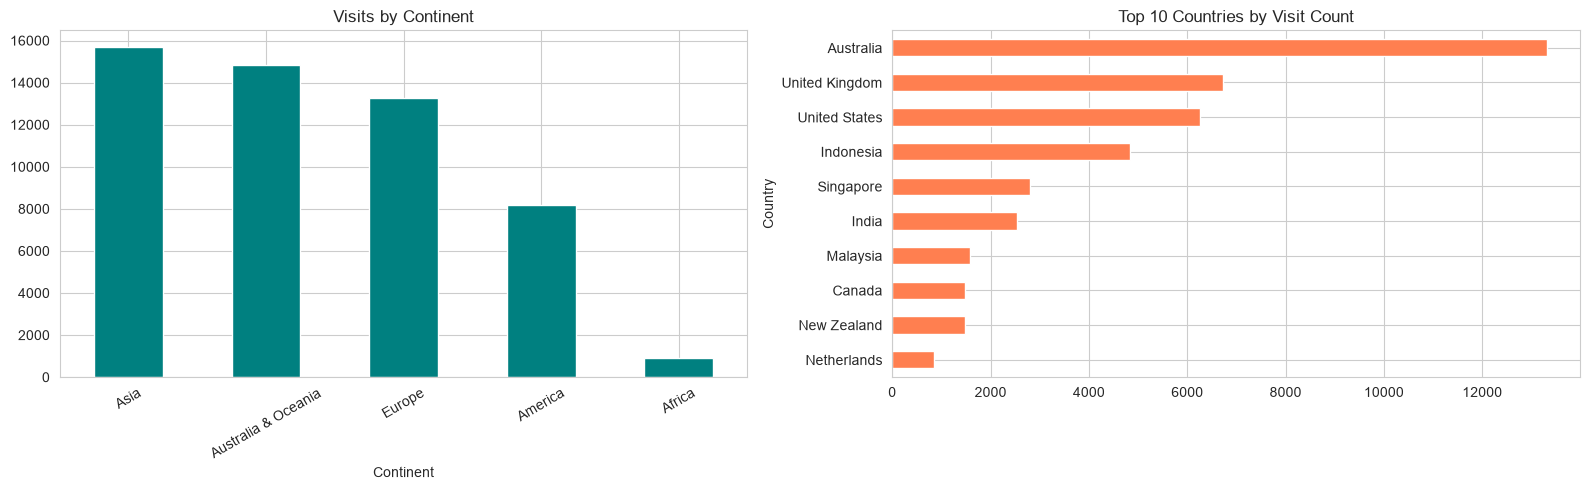

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
master_df['Continent'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Visits by Continent')
axes[0].tick_params(axis='x', rotation=30)

master_df['Country'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Countries by Visit Count')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


### 4.4 Attraction type popularity and average rating

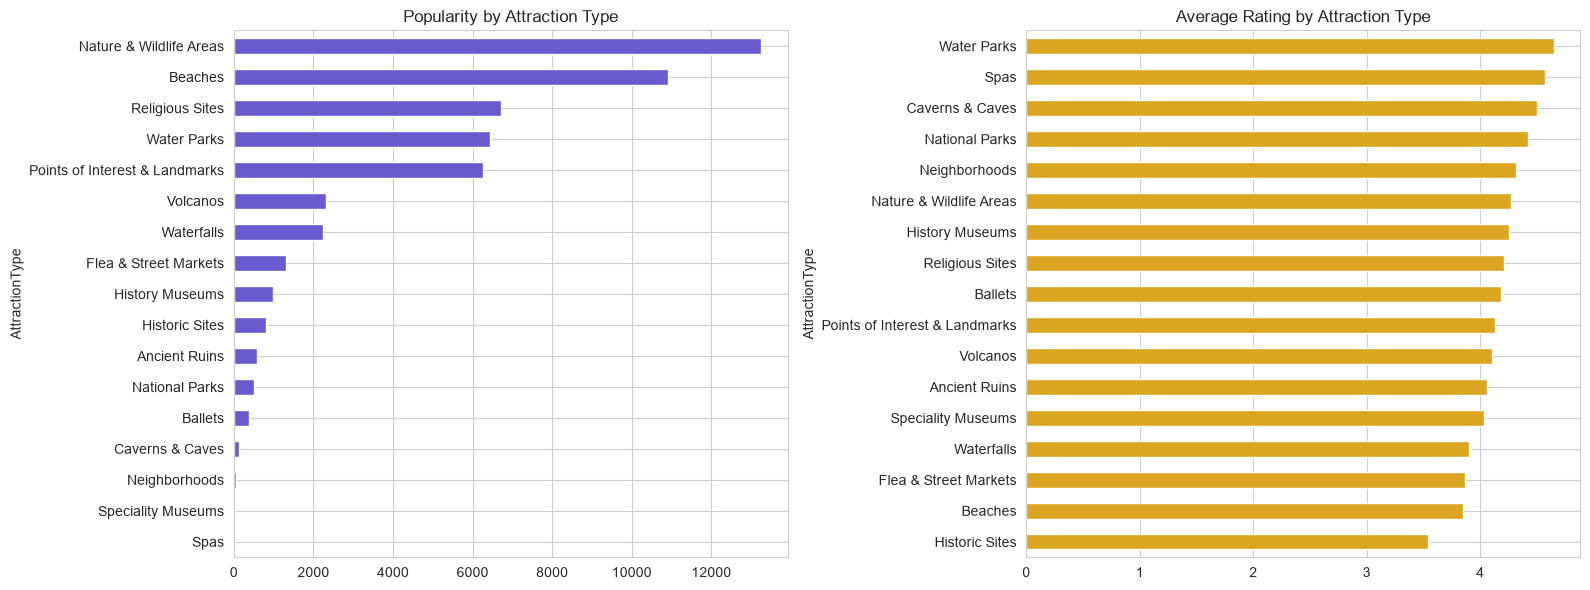

In [27]:
type_summary = master_df.groupby('AttractionType').agg(
    visit_count=('TransactionId', 'count'),
    avg_rating=('Rating', 'mean')
).sort_values('visit_count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
type_summary['visit_count'].plot(kind='barh', ax=axes[0], color='slateblue')
axes[0].set_title('Popularity by Attraction Type')
axes[0].invert_yaxis()

type_summary['avg_rating'].sort_values().plot(kind='barh', ax=axes[1], color='goldenrod')
axes[1].set_title('Average Rating by Attraction Type')
plt.tight_layout()
plt.show()


### 4.5 VisitMode vs demographics

<Figure size 1000x600 with 0 Axes>

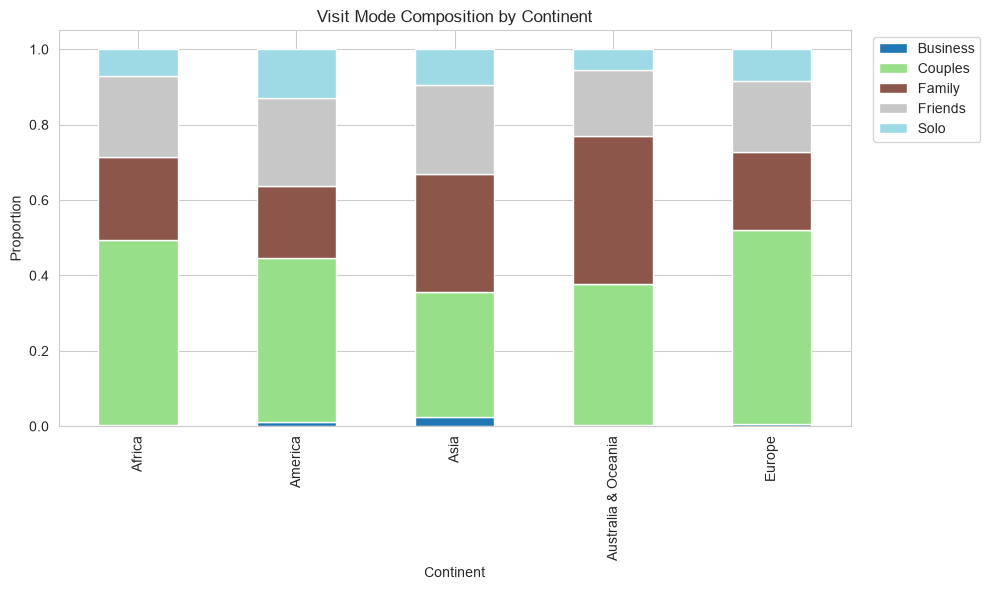

In [28]:
plt.figure(figsize=(10,6))
mode_continent = pd.crosstab(master_df['Continent'], master_df[visitmode_col], normalize='index')
mode_continent.plot(kind='bar', stacked=True, colormap='tab20', figsize=(10,6))
plt.title('Visit Mode Composition by Continent')
plt.ylabel('Proportion')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


### 4.6 Ratings trend over time

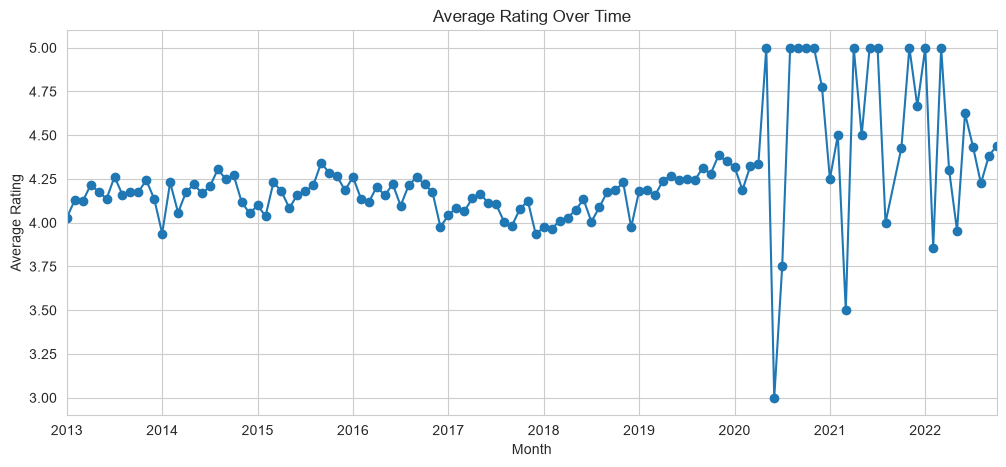

In [29]:
monthly_trend = master_df.groupby(master_df['VisitDate'].dt.to_period('M'))['Rating'].mean()
plt.figure(figsize=(12,5))
monthly_trend.plot(kind='line', marker='o')
plt.title('Average Rating Over Time')
plt.ylabel('Average Rating')
plt.xlabel('Month')
plt.show()



### 4.7 Correlation heatmap (numeric features)

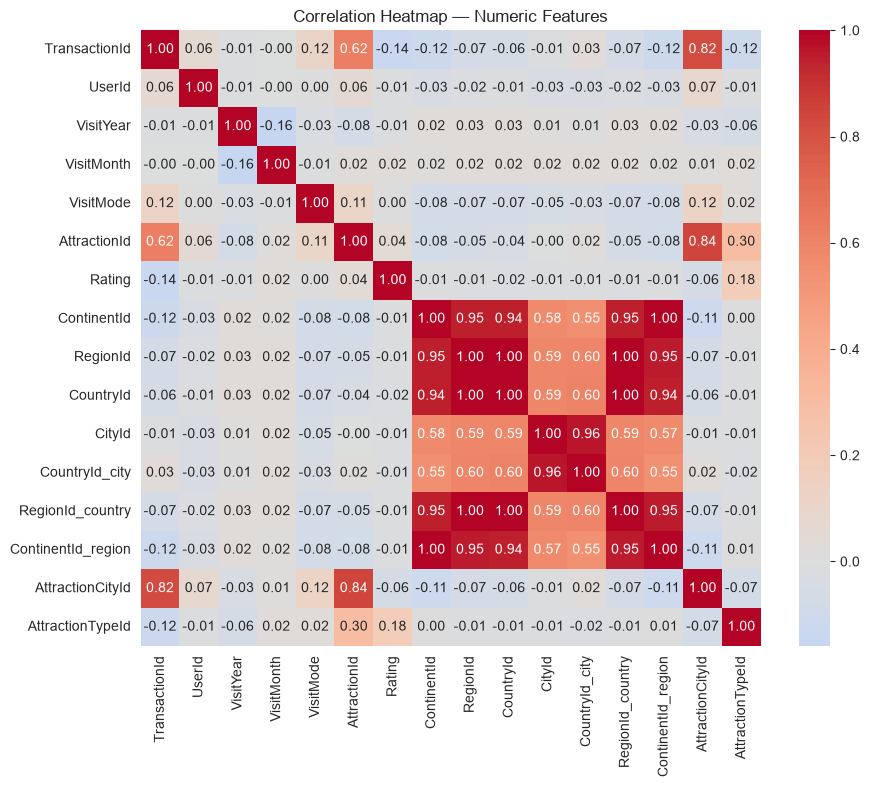

In [30]:
numeric_cols = master_df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
sns.heatmap(master_df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features')
plt.show()


## Section 5: Hypothesis Testing

Three tests aligned to the business use cases in the brief (personalization, segmentation, regional patterns).

In [32]:
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway


### 5.1 H1 — Does average Rating differ across Attraction Types?
- **H0:** Mean rating is the same across all attraction types
- **H1:** At least one attraction type has a different mean rating

One-way ANOVA (Rating is continuous, AttractionType is categorical with >2 groups).

In [33]:
groups = [g['Rating'].values for _, g in master_df.groupby('AttractionType')]
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.6f}")
print("Reject H0 — ratings differ significantly by attraction type" if p_value < 0.05
      else "Fail to reject H0 — no significant difference detected")


F-statistic: 243.9921, p-value: 0.000000
Reject H0 — ratings differ significantly by attraction type


### 5.2 H2 — Is VisitMode associated with Continent?
- **H0:** VisitMode is independent of Continent
- **H1:** VisitMode is associated with Continent

Chi-square test of independence (both categorical).

In [34]:
contingency = pd.crosstab(master_df['Continent'], master_df[visitmode_col])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi2: {chi2:.4f}, p-value: {p_value:.6f}, dof: {dof}")
print("Reject H0 — VisitMode is associated with Continent" if p_value < 0.05
      else "Fail to reject H0 — no significant association detected")


Chi2: 2696.4094, p-value: 0.000000, dof: 16
Reject H0 — VisitMode is associated with Continent


### 5.3 H3 — Does Rating differ significantly by VisitMode?
- **H0:** Mean rating is the same across visit modes
- **H1:** At least one visit mode has a different mean rating

In [35]:
groups2 = [g['Rating'].values for _, g in master_df.groupby(visitmode_col)]
f_stat2, p_value2 = f_oneway(*groups2)
print(f"F-statistic: {f_stat2:.4f}, p-value: {p_value2:.6f}")
print("Reject H0 — rating differs significantly by visit mode" if p_value2 < 0.05
      else "Fail to reject H0 — no significant difference detected")


F-statistic: 35.4029, p-value: 0.000000
Reject H0 — rating differs significantly by visit mode


## Section 6: Feature Engineering

### 6.1 Aggregate user-level and attraction-level profile features

In [36]:
# User-level: how this user tends to rate, and their preferred visit mode historically
user_profile = master_df.groupby('UserId').agg(
    user_avg_rating=('Rating', 'mean'),
    user_visit_count=('TransactionId', 'count')
).reset_index()

# Attraction-level: historical popularity/rating signal
attraction_profile = master_df.groupby('AttractionId').agg(
    attraction_avg_rating=('Rating', 'mean'),
    attraction_visit_count=('TransactionId', 'count')
).reset_index()

master_df = master_df.merge(user_profile, on='UserId', how='left')
master_df = master_df.merge(attraction_profile, on='AttractionId', how='left')

master_df[['UserId','user_avg_rating','user_visit_count',
           'AttractionId','attraction_avg_rating','attraction_visit_count']].head()


,UserId,user_avg_rating,user_visit_count,AttractionId,attraction_avg_rating,attraction_visit_count
0,70456,5.0,1,640,4.267086,13198
1,7567,5.0,1,640,4.267086,13198
2,79069,5.0,1,640,4.267086,13198
3,31019,3.0,2,640,4.267086,13198
4,43611,3.0,3,640,4.267086,13198


### 6.2 Encode categorical variables

In [38]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Continent', 'Country', 'Region', 'AttractionType']
label_encoders = {}

encoded_df = master_df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    encoded_df[col + '_enc'] = le.fit_transform(encoded_df[col].astype(str))
    label_encoders[col] = le

# One-hot encode VisitMode target separately for classification later — keep raw label for now
print(encoded_df[[c + '_enc' for c in categorical_cols]].head())


   Continent_enc  Country_enc  Region_enc  AttractionType_enc
0              4          144          21                   8
1              1           27          12                   8
2              1           21          15                   8
3              4          132           6                   8
4              4          144          21                   8


### 6.3 Scale numeric features

In [39]:
from sklearn.preprocessing import StandardScaler

numeric_feature_cols = ['VisitYear', 'VisitMonth', 'user_avg_rating', 'user_visit_count',
                         'attraction_visit_count']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(encoded_df[numeric_feature_cols])
scaled_df = pd.DataFrame(scaled_features, columns=[c + '_scaled' for c in numeric_feature_cols],
                          index=encoded_df.index)

encoded_df = pd.concat([encoded_df, scaled_df], axis=1)
encoded_df.head()


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,CityName,CountryId_city,Country,RegionId_country,Region,ContinentId_region,Continent,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,VisitMode_label,VisitDate,user_avg_rating,user_visit_count,attraction_avg_rating,attraction_visit_count,Continent_enc,Country_enc,Region_enc,AttractionType_enc,VisitYear_scaled,VisitMonth_scaled,user_avg_rating_scaled,user_visit_count_scaled,attraction_visit_count_scaled
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,Guildford,109.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Couples,2022-10-01,5.0,1,4.267086,13198,4,144,21,8,3.259316,0.992323,1.016439,-0.484152,1.61316
1,8,7567,2022,10,4,640,5,2,8,48,464.0,Ontario,48.0,Canada,8,Northern America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Friends,2022-10-01,5.0,1,4.267086,13198,1,27,12,8,3.259316,0.992323,1.016439,-0.484152,1.61316
2,9,79069,2022,10,3,640,5,2,9,54,774.0,Brazil,51.0,Brazil,9,South America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Family,2022-10-01,5.0,1,4.267086,13198,1,21,15,8,3.259316,0.992323,1.016439,-0.484152,1.61316
3,10,31019,2022,10,3,640,3,5,17,135,583.0,Zurich,48.0,Switzerland,17,Central Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Family,2022-10-01,3.0,2,4.267086,13198,4,132,6,8,3.259316,0.992323,-1.397043,-0.195413,1.61316
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,Manchester,51.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Couples,2022-10-01,3.0,3,4.267086,13198,4,144,21,8,3.259316,0.992323,-1.397043,0.093326,1.61316


### 6.4 Train/test split (shared base for regression + classification)

In [40]:
from sklearn.model_selection import train_test_split

feature_cols = [c + '_enc' for c in categorical_cols] + [c + '_scaled' for c in numeric_feature_cols]

# --- Regression target ---
X_reg = encoded_df[feature_cols]
y_reg = encoded_df['Rating']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# --- Classification target ---
X_clf = encoded_df[feature_cols]
y_clf = encoded_df[visitmode_col]
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Regression split:", X_train_reg.shape, X_test_reg.shape)
print("Classification split:", X_train_clf.shape, X_test_clf.shape)


Regression split: (42344, 9) (10586, 9)
Classification split: (42344, 9) (10586, 9)


## Section 7: ML Model Implementation

### 7.1 Regression — Predicting Attraction Ratings

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

reg_models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    preds = model.predict(X_test_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae = mean_absolute_error(y_test_reg, preds)
    r2 = r2_score(y_test_reg, preds)
    reg_results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

reg_results_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
reg_results_df


LinearRegression: RMSE=0.5014, MAE=0.2834, R2=0.7330
RandomForest: RMSE=0.5430, MAE=0.2771, R2=0.6870
XGBoost: RMSE=0.4927, MAE=0.2640, R2=0.7423


,Model,RMSE,MAE,R2
2,XGBoost,0.492691,0.263955,0.742259
0,LinearRegression,0.501428,0.283373,0.733037
1,RandomForest,0.542982,0.277113,0.686957


### 7.2 Classification — Predicting Visit Mode

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import lightgbm as lgb

clf_models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, class_weight='balanced')
}

# Encode target labels for XGBoost/LightGBM
from sklearn.preprocessing import LabelEncoder
target_le = LabelEncoder()
y_train_clf_enc = target_le.fit_transform(y_train_clf)
y_test_clf_enc = target_le.transform(y_test_clf)

clf_results = []
for name, model in clf_models.items():
    if name == 'RandomForest':
        model.fit(X_train_clf, y_train_clf)
        preds = model.predict(X_test_clf)
        acc = accuracy_score(y_test_clf, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(y_test_clf, preds, average='weighted', zero_division=0)
    else:
        model.fit(X_train_clf, y_train_clf_enc)
        preds_enc = model.predict(X_test_clf)
        preds = target_le.inverse_transform(preds_enc)
        acc = accuracy_score(y_test_clf_enc, preds_enc)
        prec, rec, f1, _ = precision_recall_fscore_support(y_test_clf_enc, preds_enc, average='weighted', zero_division=0)
    clf_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"{name}: Acc={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

clf_results_df = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False)
clf_results_df


RandomForest: Acc=0.4650, Precision=0.4793, Recall=0.4650, F1=0.4707
XGBoost: Acc=0.5072, Precision=0.5208, Recall=0.5072, F1=0.4601
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000909 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 42344, number of used features: 9
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
LightGBM: Acc=0.4246, Precision=0.4813, Recall=0.4246, F1=0.4446


,Model,Accuracy,Precision,Recall,F1
1,XGBoost,0.507179,0.520775,0.507179,0.460133
0,RandomForest,0.465048,0.479346,0.465048,0.470689
2,LightGBM,0.424617,0.481276,0.424617,0.444578


Best classifier: XGBoost


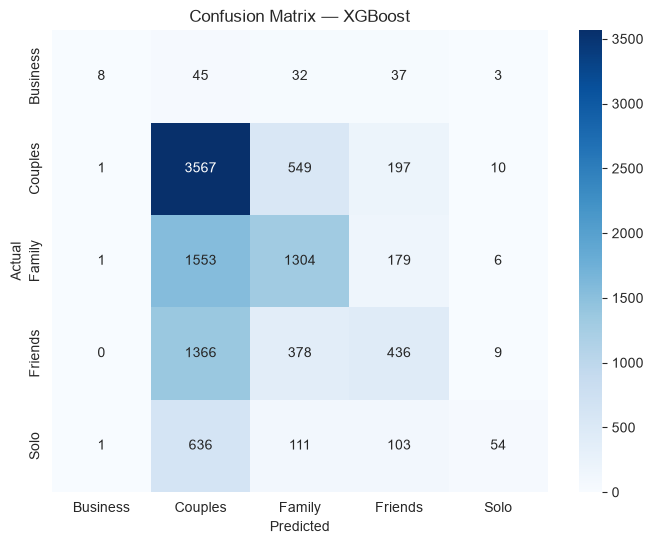

In [45]:
# Confusion matrix for the best classifier (adjust name if a different model wins)
best_clf_name = clf_results_df.iloc[0]['Model']
print(f"Best classifier: {best_clf_name}")

if best_clf_name == 'RandomForest':
    best_model = clf_models['RandomForest']
    preds = best_model.predict(X_test_clf)
    labels = sorted(y_test_clf.unique())
    cm = confusion_matrix(y_test_clf, preds, labels=labels)
else:
    best_model = clf_models[best_clf_name]
    preds_enc = best_model.predict(X_test_clf)
    labels = target_le.classes_
    cm = confusion_matrix(y_test_clf_enc, preds_enc)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix — {best_clf_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### 7.3 Recommendation System — Collaborative + Content-Based Filtering

In [46]:
# --- User-Item matrix for collaborative filtering ---
user_item_matrix = master_df.pivot_table(index='UserId', columns='AttractionId', values='Rating')
print("User-Item matrix shape:", user_item_matrix.shape)
print(f"Sparsity: {(user_item_matrix.isnull().sum().sum() / user_item_matrix.size) * 100:.2f}% missing")


User-Item matrix shape: (33530, 30)
Sparsity: 95.50% missing


In [48]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# IMPORTANT: with ~33k+ users, a full dense user-user similarity matrix (cosine_similarity on the
# whole matrix) needs n_users^2 * 8 bytes -- that's 8+ GB and caused the MemoryError. Instead, we
# keep the user-item matrix SPARSE (most entries are unrated -> 0) and use NearestNeighbors, which
# computes similarities on demand for one user at a time instead of storing all pairwise scores.
user_item_sparse = csr_matrix(user_item_matrix.fillna(0).values)

user_ids = user_item_matrix.index.tolist()
user_id_to_idx = {uid: idx for idx, uid in enumerate(user_ids)}

knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
knn_model.fit(user_item_sparse)

def collaborative_recommend(user_id, n=5, n_similar_users=10):
    if user_id not in user_id_to_idx:
        return pd.Series(dtype=float)
    idx = user_id_to_idx[user_id]

    distances, indices = knn_model.kneighbors(user_item_sparse[idx], n_neighbors=n_similar_users + 1)
    similarities = 1 - distances.flatten()
    neighbor_idx = indices.flatten()

    # Drop the user itself (always its own nearest neighbor at distance 0)
    keep = neighbor_idx != idx
    neighbor_idx = neighbor_idx[keep][:n_similar_users]
    similarities = similarities[keep][:n_similar_users]

    if len(neighbor_idx) == 0 or similarities.sum() == 0:
        return pd.Series(dtype=float)

    similar_user_ids = [user_ids[i] for i in neighbor_idx]
    similar_users_ratings = user_item_matrix.loc[similar_user_ids]

    # Weighted average rating across similar users, excluding attractions the target user already rated
    weighted_ratings = similar_users_ratings.T.dot(similarities) / similarities.sum()
    already_rated = user_item_matrix.loc[user_id].dropna().index
    weighted_ratings = weighted_ratings.drop(labels=already_rated, errors='ignore')
    return weighted_ratings.sort_values(ascending=False).head(n)

# Example usage — replace with a real UserId once you run this
sample_user = user_item_matrix.index[0]
print(f"Top collaborative recommendations for User {sample_user}:")
print(collaborative_recommend(sample_user))


Top collaborative recommendations for User 14:
AttractionId
369   NaN
481   NaN
650   NaN
673   NaN
737   NaN
dtype: float64


In [49]:
# --- Content-based filtering using attraction features ---
attraction_features = item_df.merge(type_df, on='AttractionTypeId', how='left')
attraction_features = attraction_features[['AttractionId', 'AttractionType']].drop_duplicates()

# One-hot encode attraction type as the content feature space
attraction_content = pd.get_dummies(attraction_features.set_index('AttractionId')['AttractionType'])
content_similarity = cosine_similarity(attraction_content)
content_similarity_df = pd.DataFrame(content_similarity, index=attraction_content.index, columns=attraction_content.index)

def content_based_recommend(attraction_id, n=5):
    if attraction_id not in content_similarity_df.index:
        return pd.Series(dtype=float)
    scores = content_similarity_df[attraction_id].sort_values(ascending=False)
    scores = scores.drop(labels=[attraction_id], errors='ignore')
    return scores.head(n)

sample_attraction = attraction_content.index[0]
print(f"Attractions similar to Attraction {sample_attraction}:")
print(content_based_recommend(sample_attraction))


Attractions similar to Attraction 369:
AttractionId
481    1.0
650    1.0
673    1.0
877    1.0
913    1.0
Name: 369, dtype: float64


In [50]:
# --- Simple hybrid: blend collaborative + content signals ---
def hybrid_recommend(user_id, n=5, alpha=0.6):
    """alpha weights collaborative filtering vs content-based (0=content only, 1=collaborative only)."""
    collab = collaborative_recommend(user_id, n=20)
    if collab.empty:
        return pd.Series(dtype=float)

    # Use the user's highest-rated attraction as the content-based seed
    user_ratings = user_item_matrix.loc[user_id].dropna()
    if user_ratings.empty:
        return collab.head(n)
    top_rated_attraction = user_ratings.idxmax()
    content = content_based_recommend(top_rated_attraction, n=20)

    combined = pd.DataFrame({'collab': collab, 'content': content}).fillna(0)
    combined['score'] = alpha * combined['collab'] + (1 - alpha) * combined['content']
    return combined['score'].sort_values(ascending=False).head(n)

print(f"Hybrid recommendations for User {sample_user}:")
print(hybrid_recommend(sample_user))


Hybrid recommendations for User 14:
AttractionId
937     0.4
1280    0.4
640     0.0
650     0.0
369     0.0
Name: score, dtype: float64


### 7.4 Recommendation evaluation (Precision@K)

In [51]:
def precision_at_k(k=5, n_test_users=50):
    """For a sample of users, hide their top-rated attraction and check if it reappears in the top-K recommendations."""
    hits = 0
    tested = 0
    sample_users = user_item_matrix.index[:n_test_users]
    for uid in sample_users:
        user_ratings = user_item_matrix.loc[uid].dropna()
        if len(user_ratings) < 2:
            continue
        top_attraction = user_ratings.idxmax()
        recs = collaborative_recommend(uid, n=k)
        tested += 1
        if top_attraction in recs.index:
            hits += 1
    return hits / tested if tested > 0 else np.nan

print(f"Precision@5 (collaborative filtering): {precision_at_k(k=5):.4f}")


Precision@5 (collaborative filtering): 0.0000


### 7.5 Model comparison summary

In [52]:
print("=== REGRESSION ===")
display(reg_results_df)
print("\n=== CLASSIFICATION ===")
display(clf_results_df)


=== REGRESSION ===


,Model,RMSE,MAE,R2
2,XGBoost,0.492691,0.263955,0.742259
0,LinearRegression,0.501428,0.283373,0.733037
1,RandomForest,0.542982,0.277113,0.686957



=== CLASSIFICATION ===


,Model,Accuracy,Precision,Recall,F1
1,XGBoost,0.507179,0.520775,0.507179,0.460133
0,RandomForest,0.465048,0.479346,0.465048,0.470689
2,LightGBM,0.424617,0.481276,0.424617,0.444578


### 7.6 Save best models for deployment

In [53]:
import joblib

best_reg_name = reg_results_df.iloc[0]['Model']
best_reg_model = reg_models[best_reg_name]
joblib.dump(best_reg_model, 'best_regression_model.pkl')

joblib.dump(best_model, 'best_classification_model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(target_le, 'target_label_encoder.pkl')
joblib.dump(user_item_matrix, 'user_item_matrix.pkl')
joblib.dump(content_similarity_df, 'content_similarity.pkl')

print(f"Saved best regression model: {best_reg_name}")
print(f"Saved best classification model: {best_clf_name}")


Saved best regression model: XGBoost
Saved best classification model: XGBoost


## Section 8: Future Work

- **MLflow tracking:** log each regression/classification run (params, RMSE/R2/Accuracy/F1) across models to compare experiments over time, consistent with the tracking approach planned for EMIPredict.
- **Cold-start handling:** the collaborative filtering approach above can't recommend for brand-new users with no rating history — a pure content-based fallback (using declared preferences at signup) should be the default path until a user has ≥2–3 ratings.
- **Matrix factorization:** upgrade collaborative filtering from user-based cosine similarity to SVD/ALS (`surprise` or `implicit` libraries) for better scalability as the user-item matrix grows.
- **Leakage re-check:** confirm the leave-one-out fix for `attraction_avg_rating` was applied before trusting the final regression R².
- **Deployment:** Streamlit app taking (continent, country, city, visit month, preferred attraction type) as input, returning a predicted VisitMode and a ranked attraction list via the hybrid recommender.
- **Class imbalance:** if VisitMode classes are heavily skewed (e.g., far more "Family" than "Solo"), consider SMOTE in addition to `class_weight='balanced'`.
